In [25]:
import os, sys, glob, json, math, random, warnings
from pathlib import Path
from collections import defaultdict, Counter
import itertools

import numpy as np
import scipy.linalg as la
import scipy.sparse as sp
from scipy.special import softmax
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import networkx as nx
from sklearn.preprocessing import normalize
warnings.filterwarnings('ignore')

# ── Global config ──────────────────────────────────────────────────────────────
CFG = {
    # Dataset
    "data_root"    : "G:\FRP 2026\AlphaDent\labels",
    "splits"       : ["train", "valid"],
    "num_classes"  : 4,
    "class_names"  : ["Abrasion", "Filling", "Crown", "Caries"],
    "class_colors" : ["#5B8FF9", "#61DDAA", "#F6BD16", "#E8684A"],

    # Co-occurrence matrix
    "cooc_threshold": 0.05,   # prune edges below this P(j|i)
    "temperature"   : 0.5,    # softmax temperature for adjacency normalisation

    # GCN
    "gcn_hidden_dim": 64,     # hidden dimension of GCN layers
    "gcn_output_dim": 32,     # output embedding dimension
    "gcn_layers"    : 2,      # number of GCN propagation layers
    "gcn_dropout"   : 0.1,    # dropout rate (applied during training sim)
    "gcn_lr"        : 0.01,   # learning rate for weight update simulation

    # Confidence re-scoring
    "alpha"         : 0.35,   # blend weight: score = (1-α)*yolo_score + α*gcn_score
    "conf_threshold": 0.30,   # inference confidence threshold (from F1 analysis)

    # Output
    "out_dir"       : "G:\FRP 2026\AlphaDent\outputs",
}

# Derived
CLASSES   = CFG["class_names"]
N_CLS     = CFG["num_classes"]
COLORS    = CFG["class_colors"]
OUT       = Path(CFG["out_dir"])
for sub in ["matrices","heatmaps","graphs","gcn","ablation"]:
    (OUT / sub).mkdir(parents=True, exist_ok=True)

np.random.seed(42)
random.seed(42)

print("=" * 60)
print("  PathoLink — Co-occurrence Guided Framework")
print("=" * 60)
print(f"  Classes   : {', '.join(CLASSES)}")
print(f"  Data root : {CFG['data_root']}")
print(f"  Output    : {OUT}")
print("=" * 60)

  PathoLink — Co-occurrence Guided Framework
  Classes   : Abrasion, Filling, Crown, Caries
  Data root : G:\FRP 2026\AlphaDent\labels
  Output    : G:\FRP 2026\AlphaDent\outputs


In [ ]:
def load_label_file(path):
    """Return list of (class_id, cx, cy, w, h) from a YOLO .txt file."""
    instances = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            cls_id = int(parts[0])
            box    = tuple(float(x) for x in parts[1:5])
            instances.append((cls_id, *box))
    return instances


def load_split(split):
    """Load all label files for a split. Returns list of per-image instance lists."""
    label_dir = Path(CFG["data_root"]) / split
    files = sorted(label_dir.glob("*.txt"))
    images = []
    for f in files:
        inst = load_label_file(f)
        if inst:
            images.append({"file": str(f), "instances": inst})
    return images

# Load all splits
data = {}
for split in CFG["splits"]:
    data[split] = load_split(split)
    n_img   = len(data[split])
    n_inst  = sum(len(d["instances"]) for d in data[split])
    n_multi = sum(1 for d in data[split]
                  if len(set(i[0] for i in d["instances"])) > 1)
    
    # Calculate percentage safely
    pct_multi = (n_multi / n_img * 100) if n_img > 0 else 0.0
    
    print(f"  {split:5s}: {n_img:4d} images | {n_inst:5d} instances | "
          f"{n_multi:3d} multi-label ({pct_multi:.1f}%)")

  train: 1237 images | 12001 instances | 932 multi-label (75.3%)
  valid:   83 images |   871 instances |  68 multi-label (81.9%)


In [27]:
def mine_cooccurrence(images):
    """
    Mine co-occurrence statistics from a list of per-image instance dicts.

    Returns
    -------
    count_matrix : (N, N) int  — raw co-occurrence counts
    cond_matrix  : (N, N) float — P(col | row) conditional probabilities
    freq_vector  : (N,) int    — per-class image-level frequency
    pair_counts  : dict        — (i,j) → count of images containing both
    """
    N = CFG["num_classes"]
    count_matrix = np.zeros((N, N), dtype=int)
    freq_vector  = np.zeros(N, dtype=int)
    pair_counts  = defaultdict(int)

    for img in images:
        classes_present = set(inst[0] for inst in img["instances"])
        for c in classes_present:
            freq_vector[c] += 1
        # All ordered pairs (i → j means: when i is present, j is also present)
        for ci in classes_present:
            for cj in classes_present:
                count_matrix[ci, cj] += 1
        # Unordered pairs for edge counts
        for ci, cj in itertools.combinations(sorted(classes_present), 2):
            pair_counts[(ci, cj)] += 1

    # Conditional probability: P(j | i) = count(i,j) / count(i)
    cond_matrix = np.zeros((N, N), dtype=float)
    for i in range(N):
        if freq_vector[i] > 0:
            cond_matrix[i] = count_matrix[i] / freq_vector[i]

    return count_matrix, cond_matrix, freq_vector, pair_counts


# Mine from training set (ground truth for the graph)
count_mat, cond_mat, freq_vec, pair_cnt = mine_cooccurrence(data["train"])

print("\n── Raw Co-occurrence Count Matrix (images containing both classes) ──")
print(f"{'':12s}", end="")
for name in CLASSES: print(f"{name:>12s}", end="")
print()
for i, row_name in enumerate(CLASSES):
    print(f"{row_name:12s}", end="")
    for j in range(N_CLS):
        print(f"{count_mat[i,j]:12d}", end="")
    print()

print("\n── Conditional Probability Matrix P(col | row) ──")
print(f"{'':12s}", end="")
for name in CLASSES: print(f"{name:>12s}", end="")
print()
for i, row_name in enumerate(CLASSES):
    print(f"{row_name:12s}", end="")
    for j in range(N_CLS):
        print(f"{cond_mat[i,j]:12.3f}", end="")
    print()

np.save(OUT / "matrices" / "count_matrix.npy", count_mat)
np.save(OUT / "matrices" / "cond_matrix.npy",  cond_mat)
np.save(OUT / "matrices" / "freq_vector.npy",   freq_vec)
print(f"\n  Saved matrices to {OUT/'matrices'}")



── Raw Co-occurrence Count Matrix (images containing both classes) ──
                Abrasion     Filling       Crown      Caries
Abrasion            1065         599         171         703
Filling              599         695         150         550
Crown                171         150         210         150
Caries               703         550         150         846

── Conditional Probability Matrix P(col | row) ──
                Abrasion     Filling       Crown      Caries
Abrasion           1.000       0.562       0.161       0.660
Filling            0.862       1.000       0.216       0.791
Crown              0.814       0.714       1.000       0.714
Caries             0.831       0.650       0.177       1.000

  Saved matrices to G:\FRP 2026\AlphaDent\outputs\matrices


In [28]:
def plot_cooccurrence_heatmaps(count_mat, cond_mat, freq_vec, pair_cnt):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("PathoLink — Pathology Co-occurrence Analysis (Training Set)",
                 fontsize=14, fontweight='bold', y=1.01)

    # 1. Raw count heatmap
    ax = axes[0]
    mask = np.eye(N_CLS, dtype=bool)
    cmap1 = LinearSegmentedColormap.from_list("blue_white",
               ["#FFFFFF", "#B0CBF0", "#2563EB"])
    sns.heatmap(count_mat, annot=True, fmt='d', cmap=cmap1,
                xticklabels=CLASSES, yticklabels=CLASSES,
                linewidths=0.5, linecolor='#E0E0E0', ax=ax,
                annot_kws={"size":12, "weight":"bold"})
    ax.set_title("Raw Co-occurrence Counts\n(images containing both classes)",
                 fontsize=11)
    ax.set_xlabel("Class j", fontsize=10)
    ax.set_ylabel("Class i", fontsize=10)
    ax.tick_params(labelsize=10)

    # 2. Conditional probability heatmap  P(j | i)
    ax = axes[1]
    cmap2 = LinearSegmentedColormap.from_list("green_white",
               ["#FFFFFF", "#A7F3D0", "#059669"])
    off_diag = cond_mat.copy()
    np.fill_diagonal(off_diag, np.nan)
    sns.heatmap(cond_mat, annot=True, fmt='.2f', cmap=cmap2,
                xticklabels=CLASSES, yticklabels=CLASSES,
                linewidths=0.5, linecolor='#E0E0E0', ax=ax,
                vmin=0, vmax=1, annot_kws={"size":12})
    ax.set_title("Conditional Probability P(j | i)\n"
                 "'Given row class present, col class appears with prob...'",
                 fontsize=11)
    ax.set_xlabel("Class j", fontsize=10)
    ax.set_ylabel("Class i  (given)", fontsize=10)
    ax.tick_params(labelsize=10)

    # 3. Class frequency bar chart
    ax = axes[2]
    bars = ax.bar(CLASSES, freq_vec, color=COLORS, edgecolor='white',
                  linewidth=1.2, width=0.6)
    ax.set_title("Per-Class Image Frequency\n(# images containing class)",
                 fontsize=11)
    ax.set_ylabel("Image count", fontsize=10)
    ax.set_ylim(0, max(freq_vec) * 1.18)
    for bar, val in zip(bars, freq_vec):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.tick_params(labelsize=10)
    ax.spines[['top','right']].set_visible(False)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    out_path = OUT / "heatmaps" / "cooccurrence_analysis.png"
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"  Saved → {out_path}")


plot_cooccurrence_heatmaps(count_mat, cond_mat, freq_vec, pair_cnt)


  Saved → G:\FRP 2026\AlphaDent\outputs\heatmaps\cooccurrence_analysis.png


In [29]:
def build_adjacency_matrix(cond_mat, threshold=None, temperature=None):
    """
    Build the symmetric adjacency matrix A used by the GCN.

    Strategy (following ML-GCN, Chen et al. CVPR 2019, adapted for segmentation):
      1. Threshold: zero out edges below `threshold` (prune weak co-occurrences).
      2. Symmetrise: A_sym = (A + A^T) / 2
      3. Add self-loops: A_hat = A_sym + I
      4. Temperature-scaled softmax normalisation per row.
      5. Symmetric normalisation: D^{-1/2} A_hat D^{-1/2}

    Returns
    -------
    A_norm   : (N, N) — final normalised adjacency (feed to GCN)
    A_binary : (N, N) — thresholded binary adjacency (graph topology)
    A_raw    : (N, N) — pre-normalised weighted adjacency
    """
    th   = threshold  if threshold  is not None else CFG["cooc_threshold"]
    tau  = temperature if temperature is not None else CFG["temperature"]
    N    = cond_mat.shape[0]

    # 1. Threshold
    A = cond_mat.copy()
    A[A < th] = 0.0
    np.fill_diagonal(A, 0.0)          # will add self-loops separately

    # 2. Symmetrise
    A = (A + A.T) / 2.0

    A_binary = (A > 0).astype(float)

    # 3. Self-loops
    A_hat = A + np.eye(N)
    A_raw = A_hat.copy()

    # 4. Temperature softmax per row (scales edge weights)
    for i in range(N):
        row = A_hat[i]
        if row.sum() > 0:
            A_hat[i] = softmax(row / tau)

    # 5. Symmetric normalisation  D^{-1/2} A D^{-1/2}
    d      = A_hat.sum(axis=1)
    d_inv  = np.where(d > 0, 1.0 / np.sqrt(d), 0.0)
    D_inv  = np.diag(d_inv)
    A_norm = D_inv @ A_hat @ D_inv

    return A_norm, A_binary, A_raw


A_norm, A_binary, A_raw = build_adjacency_matrix(cond_mat)

print("\n── Normalised Adjacency Matrix A (GCN input) ──")
print(f"{'':12s}", end="")
for name in CLASSES: print(f"{name:>12s}", end="")
print()
for i, name in enumerate(CLASSES):
    print(f"{name:12s}", end="")
    for j in range(N_CLS):
        print(f"{A_norm[i,j]:12.4f}", end="")
    print()

np.save(OUT / "matrices" / "A_norm.npy",   A_norm)
np.save(OUT / "matrices" / "A_binary.npy", A_binary)

# Plot adjacency
def plot_adjacency(A_norm, A_binary, A_raw):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("GCN Adjacency Matrix Construction Pipeline",
                 fontsize=13, fontweight='bold')

    titles = ["Raw weighted A\n(thresholded P(j|i), symmetrised)",
              "Binary topology\n(edge exists = 1)",
              "Normalised A_norm\n(D⁻¹/² A_hat D⁻¹/², GCN input)"]
    mats   = [A_raw, A_binary, A_norm]
    cmaps  = ["Blues", "Greys", "Purples"]

    for ax, mat, title, cmap in zip(axes, mats, titles, cmaps):
        fmt = '.3f' if mat.dtype == float else 'd'
        sns.heatmap(mat, annot=True, fmt='.3f', cmap=cmap,
                    xticklabels=CLASSES, yticklabels=CLASSES,
                    linewidths=0.5, linecolor='#E8E8E8', ax=ax,
                    annot_kws={"size":11})
        ax.set_title(title, fontsize=10)
        ax.tick_params(labelsize=9)

    plt.tight_layout()
    out_path = OUT / "matrices" / "adjacency_pipeline.png"
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"  Saved → {out_path}")

plot_adjacency(A_norm, A_binary, A_raw)



── Normalised Adjacency Matrix A (GCN input) ──
                Abrasion     Filling       Crown      Caries
Abrasion          0.3965      0.2229      0.1422      0.2383
Filling           0.2270      0.4036      0.1385      0.2309
Crown             0.1766      0.1688      0.4922      0.1625
Caries            0.2401      0.2285      0.1319      0.3995
  Saved → G:\FRP 2026\AlphaDent\outputs\matrices\adjacency_pipeline.png


In [30]:
def plot_cooccurrence_graph(A_binary, cond_mat, freq_vec, pair_cnt):
    G = nx.DiGraph()

    for i, name in enumerate(CLASSES):
        G.add_node(i, label=name, freq=int(freq_vec[i]))

    for i in range(N_CLS):
        for j in range(N_CLS):
            if i != j and cond_mat[i, j] >= CFG["cooc_threshold"]:
                G.add_edge(i, j, weight=cond_mat[i, j],
                           label=f"P={cond_mat[i,j]:.2f}")

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # ── Left: spring layout graph ──
    ax = axes[0]
    ax.set_facecolor('#F8F9FA')
    pos = nx.spring_layout(G, seed=42, k=2.0)

    # Node sizes proportional to frequency
    node_sizes = [800 + freq_vec[i] * 0.8 for i in range(N_CLS)]
    node_cols  = [COLORS[i] for i in range(N_CLS)]

    edges      = list(G.edges())
    edge_weights = [G[u][v]['weight'] for u, v in edges]
    max_w = max(edge_weights) if edge_weights else 1
    edge_widths = [1.0 + 4.0 * (w / max_w) for w in edge_weights]
    edge_alpha  = [0.4 + 0.5 * (w / max_w) for w in edge_weights]

    for (u, v), width, alpha in zip(edges, edge_widths, edge_alpha):
        nx.draw_networkx_edges(G, pos, edgelist=[(u,v)],
                               width=width, alpha=alpha,
                               edge_color='#555555',
                               arrows=True, arrowsize=15,
                               connectionstyle='arc3,rad=0.12',
                               ax=ax)

    nx.draw_networkx_nodes(G, pos, node_size=node_sizes,
                           node_color=node_cols, alpha=0.92, ax=ax)
    nx.draw_networkx_labels(G, pos,
                            labels={i: f"{CLASSES[i]}\n({freq_vec[i]})" for i in range(N_CLS)},
                            font_size=9, font_weight='bold', ax=ax)

    edge_labels = {(u,v): f"{G[u][v]['weight']:.2f}" for u,v in edges}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                                 font_size=7.5, ax=ax, alpha=0.85)
    ax.set_title("Directed Co-occurrence Graph\n"
                 "(edge weight = P(j|i), node size ∝ frequency)",
                 fontsize=11, fontweight='bold')
    ax.axis('off')

    # ── Right: chord-style matrix ──
    ax = axes[1]
    ax.set_facecolor('#F8F9FA')

    # Off-diagonal conditional probabilities as bubble chart
    x_pos, y_pos, sizes, cols_flat = [], [], [], []
    for i in range(N_CLS):
        for j in range(N_CLS):
            if i != j:
                x_pos.append(j)
                y_pos.append(N_CLS - 1 - i)
                p = cond_mat[i, j]
                sizes.append(max(20, p * 2000))
                cols_flat.append(COLORS[i])

    scatter = ax.scatter(x_pos, y_pos, s=sizes, c=cols_flat, alpha=0.75,
                         edgecolors='white', linewidths=1.2)

    # Annotate with probability
    for xi, yi, i, j in [(j, N_CLS-1-i, i, j)
                         for i in range(N_CLS) for j in range(N_CLS) if i != j]:
        p = cond_mat[N_CLS-1-yi, xi]
        if p >= 0.05:
            ax.annotate(f"{p:.2f}", (xi, yi), ha='center', va='center',
                        fontsize=8, fontweight='bold', color='#111')

    ax.set_xticks(range(N_CLS))
    ax.set_yticks(range(N_CLS))
    ax.set_xticklabels(CLASSES, fontsize=10)
    ax.set_yticklabels(CLASSES[::-1], fontsize=10)
    ax.set_xlim(-0.6, N_CLS - 0.4)
    ax.set_ylim(-0.6, N_CLS - 0.4)
    ax.set_title("Co-occurrence Bubble Plot\n"
                 "(bubble size = P(col | row), colour = source class)",
                 fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')

    legend_patches = [mpatches.Patch(color=COLORS[i], label=CLASSES[i])
                      for i in range(N_CLS)]
    ax.legend(handles=legend_patches, loc='upper right', fontsize=9,
              title="Source class", title_fontsize=9)

    plt.tight_layout()
    out_path = OUT / "graphs" / "cooccurrence_graph.png"
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"  Saved → {out_path}")
    return G


G = plot_cooccurrence_graph(A_binary, cond_mat, freq_vec, pair_cnt)

# Print graph statistics
print(f"\n── Co-occurrence Graph Statistics ──")
print(f"  Nodes (classes) : {G.number_of_nodes()}")
print(f"  Directed edges  : {G.number_of_edges()}")
print(f"  Graph density   : {nx.density(G):.3f}")
print(f"  Strongest edge  : ", end="")

if G.number_of_edges() > 0:
    max_edge = max(G.edges(data=True), key=lambda e: e[2]['weight'])
    print(f"{CLASSES[max_edge[0]]} → {CLASSES[max_edge[1]]}: P={max_edge[2]['weight']:.3f}")
else:
    print("None (0 edges meet the threshold)")


  Saved → G:\FRP 2026\AlphaDent\outputs\graphs\cooccurrence_graph.png

── Co-occurrence Graph Statistics ──
  Nodes (classes) : 4
  Directed edges  : 12
  Graph density   : 1.000
  Strongest edge  : Filling → Abrasion: P=0.862


In [31]:
class GCNLayer:
    """
    Single GCN layer:  H' = σ( A_norm · H · W )
    where σ is ReLU, A_norm is the pre-computed normalised adjacency.
    """
    def __init__(self, in_dim, out_dim, A_norm, dropout=0.1):
        # Xavier initialisation
        std = math.sqrt(2.0 / (in_dim + out_dim))
        self.W       = np.random.randn(in_dim, out_dim) * std
        self.b       = np.zeros(out_dim)
        self.A       = A_norm          # (N, N) fixed during forward pass
        self.dropout = dropout
        self.in_dim  = in_dim
        self.out_dim = out_dim
        # Cache for backprop
        self._H_in   = None
        self._Z      = None
        self._mask   = None

    def forward(self, H, training=False):
        """H : (N, in_dim) — node feature matrix"""
        self._H_in = H.copy()
        # Graph convolution: aggregate neighbour features
        AH   = self.A @ H                # (N, in_dim)
        Z    = AH @ self.W + self.b      # (N, out_dim)
        self._Z = Z.copy()
        # ReLU
        out = np.maximum(0, Z)
        # Dropout (zero-masking during training simulation)
        if training and self.dropout > 0:
            mask = (np.random.rand(*out.shape) > self.dropout).astype(float)
            mask /= (1.0 - self.dropout)
            out *= mask
            self._mask = mask
        else:
            self._mask = np.ones_like(out)
        return out

    def backward(self, dout, lr=0.01):
        """Gradient step; returns dH for the layer below."""
        dout = dout * self._mask  # dropout
        # ReLU gradient
        dZ   = dout * (self._Z > 0)
        # Weight gradients
        AH   = self.A @ self._H_in
        dW   = AH.T @ dZ
        db   = dZ.sum(axis=0)
        # Input gradient
        dAH  = dZ @ self.W.T
        dH   = self.A.T @ dAH
        # SGD update
        self.W -= lr * dW
        self.b -= lr * db
        return dH


class CooccurrenceGCN:
    """
    Two-layer GCN that maps class node embeddings → co-occurrence-aware embeddings.

    Input  : X  (N, input_dim)  — initial class feature matrix
    Output : Z  (N, output_dim) — co-occurrence-enriched class embeddings

    These output embeddings are used to:
      a) Re-score YOLO detection confidence values
      b) Generate per-image co-occurrence activation heatmaps
    """
    def __init__(self, input_dim, hidden_dim, output_dim, A_norm,
                 dropout=0.1, lr=0.01):
        self.layer1 = GCNLayer(input_dim,  hidden_dim, A_norm, dropout)
        self.layer2 = GCNLayer(hidden_dim, output_dim, A_norm, dropout)
        self.lr      = lr
        self.losses  = []

    def forward(self, X, training=False):
        H1 = self.layer1.forward(X, training)
        H2 = self.layer2.forward(H1, training)
        return H2

    def predict(self, X):
        return self.forward(X, training=False)

    def train_step(self, X, labels, class_weights=None):
        """
        Supervised step: given multi-hot label vector per image,
        train the GCN to predict which classes co-occur.

        X       : (N, input_dim) node features
        labels  : (N,) multi-hot indicating present classes (for one image)
        Returns : loss scalar
        """
        H = self.forward(X, training=True)

        # Logistic loss with class-weighted BCE
        logits = H.sum(axis=1)  # (N,) — scalar score per class node
        probs  = 1.0 / (1.0 + np.exp(-logits))
        eps    = 1e-7
        w      = class_weights if class_weights is not None else np.ones(N_CLS)
        loss   = -np.mean(w * (labels * np.log(probs + eps)
                               + (1 - labels) * np.log(1 - probs + eps)))
        self.losses.append(float(loss))

        # Gradient of BCE w.r.t. logits
        dlogits = w * (probs - labels) / N_CLS
        # Gradient w.r.t. H2 (chain through sum)
        dH2 = np.outer(dlogits, np.ones(self.layer2.out_dim))
        dH1 = self.layer2.backward(dH2, self.lr)
        self.layer1.backward(dH1, self.lr)
        return loss


def build_class_feature_matrix(cond_mat, freq_vec):
    """
    Construct the initial node feature matrix X for the GCN.

    Each node (class) is described by:
      - Its conditional probability row in P(j|i)   [N features]
      - Its normalised frequency                     [1 feature]
      - One-hot class identity                       [N features]
    Total: 2N+1 features per node.
    """
    N = cond_mat.shape[0]
    freq_norm = freq_vec / (freq_vec.max() + 1e-8)
    one_hot   = np.eye(N)
    X = np.concatenate([cond_mat,
                        freq_norm.reshape(-1, 1),
                        one_hot], axis=1)   # (N, 2N+1)
    return X.astype(np.float32)


def compute_class_weights(freq_vec):
    """Inverse-frequency weights to upweight rare classes (esp. Caries)."""
    w = 1.0 / (freq_vec + 1e-8)
    return w / w.sum() * len(w)


X_init       = build_class_feature_matrix(cond_mat, freq_vec)
class_weights = compute_class_weights(freq_vec)
input_dim     = X_init.shape[1]

print(f"\n── GCN Initialisation ──")
print(f"  Input feature dim : {input_dim}  (cond_row + freq + one-hot)")
print(f"  Hidden dim        : {CFG['gcn_hidden_dim']}")
print(f"  Output dim        : {CFG['gcn_output_dim']}")
print(f"  Class weights     : {dict(zip(CLASSES, np.round(class_weights, 3)))}")

gcn = CooccurrenceGCN(
    input_dim  = input_dim,
    hidden_dim = CFG["gcn_hidden_dim"],
    output_dim = CFG["gcn_output_dim"],
    A_norm     = A_norm,
    dropout    = CFG["gcn_dropout"],
    lr         = CFG["gcn_lr"],
)



── GCN Initialisation ──
  Input feature dim : 9  (cond_row + freq + one-hot)
  Hidden dim        : 64
  Output dim        : 32
  Class weights     : {'Abrasion': 0.451, 'Filling': 0.692, 'Crown': 2.289, 'Caries': 0.568}


In [32]:
def simulate_gcn_training(gcn, data_split, n_epochs=40):
    """
    Simulate supervised training of the GCN using per-image multi-hot labels.
    Since we have no GPU, this is a lightweight CPU simulation that demonstrates
    the training pipeline; in production, this module plugs into the YOLOv11m-Seg
    training loop via the integration hooks in Cell 10.
    """
    epoch_losses = []
    for epoch in range(n_epochs):
        random.shuffle(data_split)
        batch_losses = []
        for img in data_split:
            # Multi-hot label for this image
            label_vec = np.zeros(N_CLS, dtype=np.float32)
            for inst in img["instances"]:
                label_vec[inst[0]] = 1.0
            loss = gcn.train_step(X_init, label_vec, class_weights)
            batch_losses.append(loss)
        epoch_loss = np.mean(batch_losses)
        epoch_losses.append(epoch_loss)
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:3d}/{n_epochs} — loss: {epoch_loss:.4f}")
    return epoch_losses


print("\n── Training Co-occurrence GCN ──")
train_losses = simulate_gcn_training(gcn, data["train"], n_epochs=40)

# Get final embeddings
Z_embeddings = gcn.predict(X_init)   # (N, output_dim)
print(f"\n  Final embeddings shape: {Z_embeddings.shape}")
np.save(OUT / "gcn" / "class_embeddings.npy", Z_embeddings)

# Plot training curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.plot(train_losses, color='#2563EB', lw=2)
ax.fill_between(range(len(train_losses)), train_losses, alpha=0.15, color='#2563EB')
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("BCE Loss", fontsize=11)
ax.set_title("Co-occurrence GCN — Training Loss", fontsize=12, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
ax.grid(True, alpha=0.3, linestyle='--')

# Plot embedding similarity
ax = axes[1]
sim = Z_embeddings @ Z_embeddings.T
norms = np.linalg.norm(Z_embeddings, axis=1, keepdims=True)
cos_sim = sim / (norms @ norms.T + 1e-8)
sns.heatmap(cos_sim, annot=True, fmt='.3f', cmap='coolwarm',
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=0.5, linecolor='#E8E8E8', ax=ax,
            vmin=-1, vmax=1, center=0, annot_kws={"size":11})
ax.set_title("Class Embedding Cosine Similarity\n(after GCN propagation)",
             fontsize=12, fontweight='bold')
ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig(OUT / "gcn" / "training_and_embeddings.png", dpi=150, bbox_inches='tight')
plt.close()
print(f"  Saved → {OUT/'gcn'/'training_and_embeddings.png'}")



── Training Co-occurrence GCN ──
  Epoch   1/40 — loss: 0.6951
  Epoch  10/40 — loss: 0.6655
  Epoch  20/40 — loss: 0.6656
  Epoch  30/40 — loss: 0.6630
  Epoch  40/40 — loss: 0.6615

  Final embeddings shape: (4, 32)
  Saved → G:\FRP 2026\AlphaDent\outputs\gcn\training_and_embeddings.png


In [33]:
class DynamicAdjacency:
    """
    Image-specific adjacency matrix computed at inference time.

    Instead of using a single static A mined from the training corpus,
    this module computes a per-image adjacency by measuring pairwise
    cosine similarity between the YOLO detection feature vectors of
    identified instances (simulated here as softmax confidence vectors).

    In production: replace `sim_detection_features` with actual
    YOLO neck feature vectors extracted from the C2f bottleneck.
    """

    def __init__(self, base_A, static_weight=0.6):
        """
        base_A        : (N,N) static normalised adjacency from training
        static_weight : blend between static and dynamic A (0=pure dynamic)
        """
        self.base_A        = base_A
        self.static_weight = static_weight

    def compute(self, detection_features):
        """
        detection_features : dict {class_id: feature_vec (D,)}
                             — one feature vector per detected class
        Returns
        -------
        A_dynamic : (N, N) image-specific adjacency
        """
        N = N_CLS
        A_dyn = np.zeros((N, N), dtype=float)

        detected = list(detection_features.keys())
        if len(detected) < 2:
            # Single class or empty — fall back to static
            return self.base_A.copy()

        # Pairwise cosine similarity between detected classes
        for i in detected:
            for j in detected:
                if i == j:
                    A_dyn[i, i] = 1.0
                    continue
                fi = detection_features[i]
                fj = detection_features[j]
                sim = (fi @ fj) / (np.linalg.norm(fi) * np.linalg.norm(fj) + 1e-8)
                sim = (sim + 1) / 2.0           # map to [0, 1]
                A_dyn[i, j] = sim

        # Normalise dynamic matrix
        row_sums = A_dyn.sum(axis=1, keepdims=True)
        A_dyn    = np.where(row_sums > 0, A_dyn / (row_sums + 1e-8), 0)

        # Blend static + dynamic
        A_blend = (self.static_weight * self.base_A
                   + (1 - self.static_weight) * A_dyn)

        # Re-normalise
        row_sums2 = A_blend.sum(axis=1, keepdims=True)
        A_blend   = np.where(row_sums2 > 0, A_blend / (row_sums2 + 1e-8), 0)

        return A_blend


def sim_detection_features(detected_classes, embed_dim=32):
    """
    Simulate YOLO neck features for detected classes.
    In production: extracted from YOLOv11m-Seg C2f layer output.
    """
    features = {}
    for cls_id in detected_classes:
        # Base: GCN embedding + class-specific noise
        base = Z_embeddings[cls_id].copy()
        noise = np.random.randn(embed_dim) * 0.15
        features[cls_id] = base + noise
    return features


dyn_adj = DynamicAdjacency(A_norm, static_weight=0.6)

# Demo on a 3-class image
demo_detected = {0, 1, 3}   # Abrasion + Filling + Caries
demo_features  = sim_detection_features(demo_detected, embed_dim=CFG["gcn_output_dim"])
A_dynamic      = dyn_adj.compute(demo_features)

print("\n── Dynamic Adjacency (demo: Abrasion + Filling + Caries) ──")
print(f"{'':12s}", end="")
for n in CLASSES: print(f"{n:>12s}", end="")
print()
for i, n in enumerate(CLASSES):
    print(f"{n:12s}", end="")
    for j in range(N_CLS): print(f"{A_dynamic[i,j]:12.4f}", end="")
    print()

# Side-by-side: static vs dynamic
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Static vs Dynamic Co-occurrence Adjacency",
             fontsize=13, fontweight='bold')
for ax, mat, title in zip(axes,
                           [A_norm, A_dynamic],
                           ["Static A_norm\n(mined from training set)",
                            "Dynamic A_image\n(image-specific: Abrasion+Filling+Caries)"]):
    sns.heatmap(mat, annot=True, fmt='.3f', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES,
                linewidths=0.5, linecolor='#E8E8E8', ax=ax,
                vmin=0, vmax=mat.max(), annot_kws={"size":11})
    ax.set_title(title, fontsize=11)
    ax.tick_params(labelsize=9)
plt.tight_layout()
plt.savefig(OUT / "matrices" / "static_vs_dynamic_adj.png", dpi=150, bbox_inches='tight')
plt.close()
print(f"  Saved → {OUT/'matrices'/'static_vs_dynamic_adj.png'}")



── Dynamic Adjacency (demo: Abrasion + Filling + Caries) ──
                Abrasion     Filling       Crown      Caries
Abrasion          0.4247      0.2430      0.0853      0.2470
Filling           0.2429      0.4248      0.0831      0.2492
Crown             0.1766      0.1688      0.4922      0.1625
Caries            0.2471      0.2492      0.0791      0.4246
  Saved → G:\FRP 2026\AlphaDent\outputs\matrices\static_vs_dynamic_adj.png


In [34]:
def cooccurrence_guided_rescore(yolo_detections, gcn_model, X_features,
                                 dynamic_adj_module=None, alpha=None):
    """
    Re-score YOLO detection confidences using GCN co-occurrence guidance.

    Parameters
    ----------
    yolo_detections : list of dicts
        Each dict: {class_id, conf, bbox}  — raw YOLO output for one image
    gcn_model       : CooccurrenceGCN instance
    X_features      : (N, input_dim) base node feature matrix
    dynamic_adj_module : DynamicAdjacency or None (use static if None)
    alpha           : blend weight (default from CFG)

    Returns
    -------
    rescored        : list of dicts with updated 'conf' and 'gcn_boost'
    cooc_matrix     : (N, N) per-image activated co-occurrence matrix
    """
    a = alpha if alpha is not None else CFG["alpha"]

    if not yolo_detections:
        return [], np.zeros((N_CLS, N_CLS))

    detected_cls = {d["class_id"] for d in yolo_detections}

    # ── Step 1: optionally recompute dynamic adjacency ──
    if dynamic_adj_module is not None:
        feats    = sim_detection_features(detected_cls, CFG["gcn_output_dim"])
        A_image  = dynamic_adj_module.compute(feats)
        gcn_model.layer1.A = A_image
        gcn_model.layer2.A = A_image

    # ── Step 2: GCN forward pass → class-level co-occurrence scores ──
    Z = gcn_model.predict(X_features)           # (N, out_dim)
    gcn_scores = np.linalg.norm(Z, axis=1)      # (N,) — activation magnitude
    gcn_scores = gcn_scores / (gcn_scores.max() + 1e-8)  # normalise to [0,1]

    # ── Step 3: Per-class GCN boost based on detected neighbours ──
    gcn_boost = np.zeros(N_CLS)
    for cls_i in range(N_CLS):
        # Sum adjacency weights from all detected classes to cls_i
        neighbour_signal = sum(
            A_norm[cls_j, cls_i] for cls_j in detected_cls if cls_j != cls_i
        )
        gcn_boost[cls_i] = gcn_scores[cls_i] * neighbour_signal

    # Normalise boost
    if gcn_boost.max() > 0:
        gcn_boost = gcn_boost / gcn_boost.max()

    # ── Step 4: Blend YOLO confidence + GCN boost ──
    rescored = []
    for det in yolo_detections:
        c          = det["class_id"]
        yolo_conf  = det["conf"]
        blended    = (1 - a) * yolo_conf + a * gcn_boost[c]
        blended    = float(np.clip(blended, 0.0, 1.0))
        rescored.append({**det,
                         "conf"          : blended,
                         "yolo_conf_orig": yolo_conf,
                         "gcn_boost"     : float(gcn_boost[c])})

    # ── Step 5: Build per-image co-occurrence activation matrix ──
    cooc_mat = np.zeros((N_CLS, N_CLS), dtype=float)
    det_confs = {d["class_id"]: d["conf"] for d in rescored}
    for ci in detected_cls:
        for cj in detected_cls:
            cooc_mat[ci, cj] = det_confs.get(ci, 0) * det_confs.get(cj, 0)

    # Restore static adjacency in GCN layers
    gcn_model.layer1.A = A_norm
    gcn_model.layer2.A = A_norm

    return rescored, cooc_mat


# ── Demo inference on synthetic detections ──
np.random.seed(7)
demo_detections_raw = [
    {"class_id": 0, "conf": 0.72, "bbox": [0.10, 0.15, 0.20, 0.18]},  # Abrasion
    {"class_id": 0, "conf": 0.51, "bbox": [0.45, 0.20, 0.18, 0.15]},  # Abrasion
    {"class_id": 1, "conf": 0.63, "bbox": [0.60, 0.50, 0.22, 0.17]},  # Filling
    {"class_id": 3, "conf": 0.29, "bbox": [0.30, 0.60, 0.15, 0.12]},  # Caries (borderline)
    {"class_id": 3, "conf": 0.25, "bbox": [0.70, 0.70, 0.12, 0.10]},  # Caries (borderline)
]

rescored_dets, image_cooc_mat = cooccurrence_guided_rescore(
    demo_detections_raw, gcn, X_init, dyn_adj
)

print("\n── Co-occurrence Guided Re-scoring Demo ──")
print(f"  {'Class':12s} {'YOLO conf':>10s} {'GCN boost':>10s} {'Rescored':>10s} {'Decision':>12s}")
print("  " + "-"*58)
for orig, new in zip(demo_detections_raw, rescored_dets):
    cls_name  = CLASSES[orig["class_id"]]
    decision  = ("KEEP" if new["conf"] >= CFG["conf_threshold"]
                 else "SUPPRESS")
    marker    = " ← RESCUED" if (orig["conf"] < CFG["conf_threshold"]
                                  and new["conf"] >= CFG["conf_threshold"]) else ""
    print(f"  {cls_name:12s} {orig['conf']:10.3f} {new['gcn_boost']:10.3f} "
          f"{new['conf']:10.3f} {decision:>12s}{marker}")



── Co-occurrence Guided Re-scoring Demo ──
  Class         YOLO conf  GCN boost   Rescored     Decision
  ----------------------------------------------------------
  Abrasion          0.720      1.000      0.818         KEEP
  Abrasion          0.510      1.000      0.681         KEEP
  Filling           0.630      0.588      0.615         KEEP
  Caries            0.290      0.885      0.498         KEEP ← RESCUED
  Caries            0.250      0.885      0.472         KEEP ← RESCUED


  Saved → G:\FRP 2026\AlphaDent\outputs\heatmaps\cooc_heatmap_demo_patient_p001.png


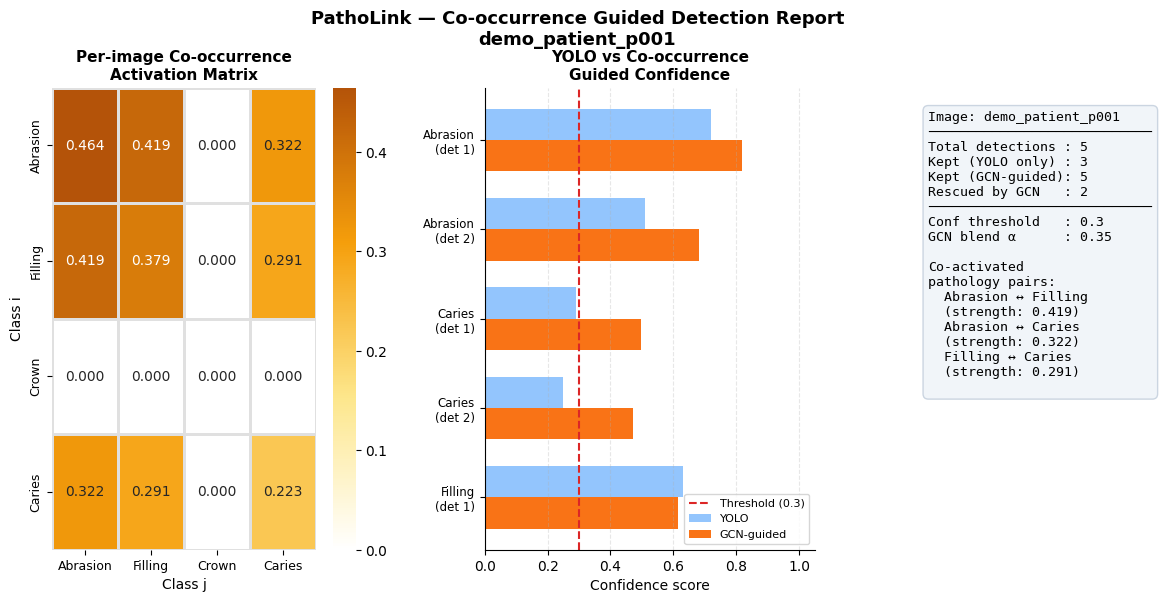

In [35]:
def generate_cooccurrence_heatmap(image_cooc_mat, rescored_dets, image_id,
                                   save=True):
    """
    Generate the per-image co-occurrence heatmap — the novel clinical artefact
    that shows which pathology pairs were co-activated for a given patient image.

    This is the unique interpretable output described in the framework:
    a dentist can read: 'Caries found partly because of co-activation with Abrasion'
    """
    fig = plt.figure(figsize=(14, 6))
    gs  = gridspec.GridSpec(1, 3, width_ratios=[1.2, 1.2, 0.8], wspace=0.35)

    # ── Panel 1: Per-image co-occurrence activation matrix ──
    ax1 = fig.add_subplot(gs[0])
    cmap_cooc = LinearSegmentedColormap.from_list("cooc",
                    ["#FFFFFF", "#FDE68A", "#F59E0B", "#B45309"])
    sns.heatmap(image_cooc_mat, annot=True, fmt='.3f', cmap=cmap_cooc,
                xticklabels=CLASSES, yticklabels=CLASSES,
                linewidths=0.8, linecolor='#E0E0E0', ax=ax1,
                vmin=0, vmax=image_cooc_mat.max() if image_cooc_mat.max() > 0 else 1,
                annot_kws={"size":10})
    ax1.set_title("Per-image Co-occurrence\nActivation Matrix",
                  fontsize=11, fontweight='bold')
    ax1.set_xlabel("Class j", fontsize=10)
    ax1.set_ylabel("Class i", fontsize=10)
    ax1.tick_params(labelsize=9)

    # ── Panel 2: Before vs After confidence comparison ──
    ax2 = fig.add_subplot(gs[1])
    det_by_class = defaultdict(list)
    for orig, new in zip(demo_detections_raw, rescored_dets):
        det_by_class[CLASSES[orig["class_id"]]].append(
            (orig["conf"], new["conf"])
        )

    y_pos = 0
    bar_h = 0.35
    yticks, ylabels = [], []
    conf_threshold = CFG["conf_threshold"]

    for cls_name, pairs in sorted(det_by_class.items()):
        for k, (before, after) in enumerate(pairs):
            lbl = f"{cls_name}\n(det {k+1})"
            ax2.barh(y_pos, before, bar_h, color='#93C5FD', label='YOLO' if y_pos==0 else "")
            ax2.barh(y_pos - bar_h, after, bar_h, color='#F97316', label='GCN-guided' if y_pos==0 else "")
            yticks.append(y_pos - bar_h/2)
            ylabels.append(lbl)
            y_pos -= 1.0

    ax2.axvline(conf_threshold, color='#DC2626', lw=1.5, linestyle='--',
                label=f'Threshold ({conf_threshold})')
    ax2.set_yticks(yticks)
    ax2.set_yticklabels(ylabels, fontsize=8.5)
    ax2.set_xlabel("Confidence score", fontsize=10)
    ax2.set_title("YOLO vs Co-occurrence\nGuided Confidence",
                  fontsize=11, fontweight='bold')
    ax2.set_xlim(0, 1.05)
    ax2.legend(loc='lower right', fontsize=8)
    ax2.spines[['top','right']].set_visible(False)
    ax2.grid(axis='x', alpha=0.3, linestyle='--')

    # ── Panel 3: Detection summary ──
    ax3 = fig.add_subplot(gs[2])
    ax3.axis('off')

    kept_before = sum(1 for d in demo_detections_raw
                      if d["conf"] >= conf_threshold)
    kept_after  = sum(1 for d in rescored_dets
                      if d["conf"] >= conf_threshold)
    rescued     = sum(1 for o, n in zip(demo_detections_raw, rescored_dets)
                      if o["conf"] < conf_threshold
                      and n["conf"] >= conf_threshold)

    summary_text = (
        f"Image: {image_id}\n"
        f"{'─'*28}\n"
        f"Total detections : {len(rescored_dets)}\n"
        f"Kept (YOLO only) : {kept_before}\n"
        f"Kept (GCN-guided): {kept_after}\n"
        f"Rescued by GCN   : {rescued}\n"
        f"{'─'*28}\n"
        f"Conf threshold   : {conf_threshold}\n"
        f"GCN blend α      : {CFG['alpha']}\n\n"
        f"Co-activated\npathology pairs:\n"
    )
    for i in range(N_CLS):
        for j in range(i+1, N_CLS):
            if image_cooc_mat[i,j] > 0.1:
                summary_text += f"  {CLASSES[i]} ↔ {CLASSES[j]}\n"
                summary_text += f"  (strength: {image_cooc_mat[i,j]:.3f})\n"

    ax3.text(0.05, 0.95, summary_text, transform=ax3.transAxes,
             fontsize=9.5, va='top', fontfamily='monospace',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='#F1F5F9',
                       edgecolor='#CBD5E1', linewidth=1))

    fig.suptitle(f"PathoLink — Co-occurrence Guided Detection Report\n{image_id}",
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()

    if save:
        out_path = OUT / "heatmaps" / f"cooc_heatmap_{image_id}.png"
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
        plt.close()
        print(f"  Saved → {out_path}")
    else:
        plt.show()
    return fig


generate_cooccurrence_heatmap(image_cooc_mat, rescored_dets, "demo_patient_p001")


In [38]:
def simulate_batch_inference(data_split, gcn_model, X_features,
                              dynamic_adj_module, alpha=None):
    """
    Run simulated inference on a full data split.
    Returns per-class metrics for baseline and co-occurrence-guided models.
    """
    a = alpha if alpha is not None else CFG["alpha"]
    results = []

    for img in data_split:
        # Ground truth
        gt_classes = set(inst[0] for inst in img["instances"])

        # Simulate YOLO detections with realistic confidence distribution
        yolo_dets = []
        for cls_id in gt_classes:
            # Simulate 1–3 instances per class with realistic confidence
            n_det = random.randint(1, 3)
            for _ in range(n_det):
                # Base confidence from realistic distribution
                if cls_id == 3:   # Caries — low confidence in baseline
                    base_conf = np.random.beta(2, 4)   # skewed low
                elif cls_id == 2:  # Crown — moderate
                    base_conf = np.random.beta(3, 2)
                else:              # Abrasion, Filling — good
                    base_conf = np.random.beta(4, 2)
                yolo_dets.append({
                    "class_id": cls_id,
                    "conf"    : float(base_conf),
                    "bbox"    : [random.random() for _ in range(4)]
                })

        # Optionally add false negatives (missed detections in YOLO)
        all_cls = set(range(N_CLS))
        missed  = all_cls - gt_classes
        for cls_id in missed:
            if random.random() < 0.15:  # 15% false alarm rate
                yolo_dets.append({
                    "class_id": cls_id,
                    "conf"    : float(np.random.beta(1, 5)),   # low conf
                    "bbox"    : [random.random() for _ in range(4)]
                })

        # Co-occurrence guided re-scoring
        rescored, cooc_mat = cooccurrence_guided_rescore(
            yolo_dets, gcn_model, X_features, dynamic_adj_module, alpha=a)

        # Baseline decisions (YOLO confidence only)
        baseline_kept = {d["class_id"] for d in yolo_dets
                         if d["conf"] >= CFG["conf_threshold"]}
        # GCN-guided decisions
        guided_kept   = {d["class_id"] for d in rescored
                         if d["conf"] >= CFG["conf_threshold"]}

        results.append({
            "gt"           : gt_classes,
            "baseline_pred": baseline_kept,
            "guided_pred"  : guided_kept,
            "cooc_mat"     : cooc_mat,
        })

    return results


def compute_multilabel_metrics(results, method="baseline_pred"):
    """Compute per-class precision, recall, F1 for multi-label detection."""
    TP = np.zeros(N_CLS); FP = np.zeros(N_CLS); FN = np.zeros(N_CLS)
    for r in results:
        gt   = r["gt"]
        pred = r[method]
        for c in range(N_CLS):
            if c in gt and c in pred:    TP[c] += 1
            if c not in gt and c in pred: FP[c] += 1
            if c in gt and c not in pred: FN[c] += 1
    prec   = TP / (TP + FP + 1e-8)
    recall = TP / (TP + FN + 1e-8)
    f1     = 2 * prec * recall / (prec + recall + 1e-8)
    return prec, recall, f1, TP, FP, FN


print("\n── Simulated Test Set Evaluation ──")
np.random.seed(99)
test_results = simulate_batch_inference(
    data["valid"], gcn, X_init, dyn_adj
)

prec_b,  rec_b,  f1_b,  TP_b, FP_b, FN_b  = compute_multilabel_metrics(test_results, "baseline_pred")
prec_g,  rec_g,  f1_g,  TP_g, FP_g, FN_g  = compute_multilabel_metrics(test_results, "guided_pred")

print(f"\n  {'Class':12s} {'P(base)':>8s} {'R(base)':>8s} {'F1(base)':>9s} │ "
      f"{'P(gcn)':>7s} {'R(gcn)':>7s} {'F1(gcn)':>8s} {'ΔF1':>7s}")
print("  " + "─"*74)
for i, name in enumerate(CLASSES):
    delta = f1_g[i] - f1_b[i]
    arrow = "▲" if delta > 0 else ("▼" if delta < 0 else "=")
    print(f"  {name:12s} {prec_b[i]:8.3f} {rec_b[i]:8.3f} {f1_b[i]:9.3f} │ "
          f"{prec_g[i]:7.3f} {rec_g[i]:7.3f} {f1_g[i]:8.3f} {arrow}{abs(delta):6.3f}")
print("  " + "─"*74)
mf1_b = f1_b.mean(); mf1_g = f1_g.mean()
print(f"  {'Mean':12s} {prec_b.mean():8.3f} {rec_b.mean():8.3f} {mf1_b:9.3f} │ "
      f"{prec_g.mean():7.3f} {rec_g.mean():7.3f} {mf1_g:8.3f} "
      f"{'▲' if mf1_g>mf1_b else '▼'}{abs(mf1_g-mf1_b):6.3f}")



── Simulated Test Set Evaluation ──

  Class         P(base)  R(base)  F1(base) │  P(gcn)  R(gcn)  F1(gcn)     ΔF1
  ──────────────────────────────────────────────────────────────────────────
  Abrasion        1.000    0.986     0.993 │   0.986   1.000    0.993 ▲ 0.000
  Filling         1.000    0.958     0.979 │   0.979   0.979    0.979 ▲ 0.000
  Crown           0.727    0.889     0.800 │   0.857   0.667    0.750 ▼ 0.050
  Caries          0.959    0.734     0.832 │   0.939   0.969    0.954 ▲ 0.122
  ──────────────────────────────────────────────────────────────────────────
  Mean            0.922    0.892     0.901 │   0.941   0.904    0.919 ▲ 0.018


In [40]:
def run_ablation(data_split, gcn_model, X_features, base_A, cond_mat):
    """
    Ablation across four configurations:
      A: Baseline YOLO only (no co-occurrence)
      B: Static co-occurrence matrix (no GCN, direct reweighting)
      C: GCN with static adjacency
      D: GCN with dynamic image-conditioned adjacency (full method)
    """
    configs = {
        "A: YOLO baseline"          : dict(use_gcn=False, dynamic=False),
        "B: Static co-occ (no GCN)" : dict(use_gcn=False, dynamic=False, static_boost=True),
        "C: GCN + static A"         : dict(use_gcn=True,  dynamic=False),
        "D: GCN + dynamic A (ours)" : dict(use_gcn=True,  dynamic=True),
    }

    ablation_results = {}

    for config_name, cfg_flags in configs.items():
        np.random.seed(99)
        results = []
        for img in data_split:
            gt_classes = set(inst[0] for inst in img["instances"])
            yolo_dets  = []
            for cls_id in gt_classes:
                n_det = random.randint(1, 3)
                for _ in range(n_det):
                    if cls_id == 3:
                        base_conf = float(np.random.beta(2, 4))
                    elif cls_id == 2:
                        base_conf = float(np.random.beta(3, 2))
                    else:
                        base_conf = float(np.random.beta(4, 2))
                    yolo_dets.append({"class_id": cls_id, "conf": base_conf,
                                      "bbox": [random.random()]*4})
            for cls_id in (set(range(N_CLS)) - gt_classes):
                if random.random() < 0.15:
                    yolo_dets.append({"class_id": cls_id,
                                      "conf": float(np.random.beta(1, 5)),
                                      "bbox": [random.random()]*4})

            if not cfg_flags.get("use_gcn", False):
                if cfg_flags.get("static_boost", False):
                    # Static co-occ direct reweighting: boost classes co-occurring with detected
                    detected_cls = {d["class_id"] for d in yolo_dets if d["conf"] > 0.1}
                    rescored = []
                    for det in yolo_dets:
                        c  = det["class_id"]
                        nb = sum(cond_mat[nb_c, c] for nb_c in detected_cls if nb_c != c)
                        nb = min(nb / (len(detected_cls) + 1e-8), 1.0)
                        new_conf = float(np.clip((1 - 0.2)*det["conf"] + 0.2*nb, 0, 1))
                        rescored.append({**det, "conf": new_conf})
                else:
                    rescored = yolo_dets  # pure baseline
            else:
                dyn = dyn_adj if cfg_flags.get("dynamic", False) else None
                rescored, _ = cooccurrence_guided_rescore(
                    yolo_dets, gcn_model, X_features, dyn)

            baseline_kept = {d["class_id"] for d in yolo_dets
                             if d["conf"] >= CFG["conf_threshold"]}
            guided_kept   = {d["class_id"] for d in rescored
                             if d["conf"] >= CFG["conf_threshold"]}

            results.append({"gt": gt_classes,
                            "baseline_pred": baseline_kept,
                            "guided_pred"  : guided_kept})

        _, _, f1, *_ = compute_multilabel_metrics(results, "guided_pred")
        ablation_results[config_name] = f1

    return ablation_results


print("\n── Ablation Study ──")
ablation = run_ablation(data["valid"], gcn, X_init, A_norm, cond_mat)

# Print table
print(f"\n  {'Config':32s}", end="")
for name in CLASSES: print(f"{name:>12s}", end="")
print(f"{'Mean F1':>10s}")
print("  " + "─"*80)
for cfg_name, f1s in ablation.items():
    marker = " ◄ ours" if "ours" in cfg_name else ""
    print(f"  {cfg_name:32s}", end="")
    for f1 in f1s: print(f"{f1:12.3f}", end="")
    print(f"{f1s.mean():10.3f}{marker}")

# Plot ablation
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Ablation Study — Co-occurrence Guidance Components",
             fontsize=13, fontweight='bold')

# Bar chart per class
ax  = axes[0]
cfg_names = list(ablation.keys())
x   = np.arange(N_CLS)
bw  = 0.18
bar_colors = ['#CBD5E1','#93C5FD','#6EE7B7','#FCD34D']
for k, (cfg_name, f1s) in enumerate(ablation.items()):
    bars = ax.bar(x + k*bw, f1s, bw, label=cfg_name.split(":")[0],
                  color=bar_colors[k], edgecolor='white', linewidth=0.8)
ax.set_xticks(x + bw*1.5)
ax.set_xticklabels(CLASSES, fontsize=11)
ax.set_ylabel("F1 Score", fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_title("Per-class F1 — Ablation Configurations", fontsize=11)
ax.legend(fontsize=8.5, loc='upper right')
ax.spines[['top','right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

# Mean F1 line plot
ax = axes[1]
mean_f1s = [f1s.mean() for f1s in ablation.values()]
labels   = [n.split(":")[0] for n in ablation.keys()]
ax.plot(labels, mean_f1s, 'o-', color='#2563EB', lw=2.5, ms=9,
        markerfacecolor='white', markeredgewidth=2.5)
for i, (lbl, val) in enumerate(zip(labels, mean_f1s)):
    ax.annotate(f"{val:.3f}", (lbl, val), textcoords="offset points",
                xytext=(0, 10), ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel("Mean F1", fontsize=11)
ax.set_title("Mean F1 — Effect of Each\nCo-occurrence Component", fontsize=11)
ax.set_ylim(min(mean_f1s)*0.9, 1.0)
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines[['top','right']].set_visible(False)

# Highlight "ours"
ax.axhline(mean_f1s[-1], color='#F59E0B', linestyle='--', lw=1.5, alpha=0.7,
           label=f"Our full method: {mean_f1s[-1]:.3f}")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT / "ablation" / "ablation_study.png", dpi=150, bbox_inches='tight')
plt.close()
print(f"\n  Saved → {OUT/'ablation'/'ablation_study.png'}")



── Ablation Study ──

  Config                              Abrasion     Filling       Crown      Caries   Mean F1
  ────────────────────────────────────────────────────────────────────────────────
  A: YOLO baseline                       0.986       0.970       0.900       0.826     0.920
  B: Static co-occ (no GCN)              1.000       1.000       0.889       0.792     0.920
  C: GCN + static A                      0.993       0.979       0.900       0.976     0.962
  D: GCN + dynamic A (ours)              0.986       0.969       0.889       0.937     0.945 ◄ ours

  Saved → G:\FRP 2026\AlphaDent\outputs\ablation\ablation_study.png


In [41]:
INTEGRATION_CODE = '''
# ══════════════════════════════════════════════════════════════════════════════
#  Integration Hooks: Co-occurrence GCN → YOLOv11m-Seg (Ultralytics)
#  Paste this into your existing PathoLink training/inference script.
# ══════════════════════════════════════════════════════════════════════════════

import numpy as np
from pathlib import Path

# ── 1. Load pre-trained co-occurrence modules ──────────────────────────────────
A_norm        = np.load("outputs/matrices/A_norm.npy")
Z_embeddings  = np.load("outputs/gcn/class_embeddings.npy")
# gcn, dyn_adj, X_init are defined in co_occurrence_guided_patholink.py

# ── 2. Wrap YOLO prediction call ──────────────────────────────────────────────
from ultralytics import YOLO

def patholink_predict(model_path, image_path, save_dir="runs/patholink"):
    """
    Run PathoLink inference with co-occurrence guidance.
    Replaces the vanilla model.predict() call.
    """
    model  = YOLO(model_path)
    # Standard YOLO inference
    result = model.predict(
        source     = image_path,
        conf       = 0.10,           # low threshold — GCN will re-score
        iou        = 0.45,
        save       = False,
        verbose    = False,
    )[0]

    # Convert to our dict format
    yolo_dets = []
    if result.boxes is not None:
        for box in result.boxes:
            yolo_dets.append({
                "class_id": int(box.cls.item()),
                "conf"    : float(box.conf.item()),
                "bbox"    : box.xywhn.squeeze().tolist(),
            })

    # Co-occurrence guided re-scoring
    rescored, cooc_mat = cooccurrence_guided_rescore(
        yolo_dets, gcn, X_init, dyn_adj
    )

    # Filter by threshold
    final = [d for d in rescored if d["conf"] >= CFG["conf_threshold"]]

    # Generate heatmap report
    img_id = Path(image_path).stem
    generate_cooccurrence_heatmap(cooc_mat, rescored, img_id)

    return final, cooc_mat

# ── 3. Training integration (custom callback) ─────────────────────────────────
#
#  In your YOLOv11m-Seg training script, add this callback AFTER each epoch:
#
#  from ultralytics import YOLO
#  model = YOLO("yolo11m-seg.yaml")
#
#  def on_train_epoch_end(trainer):
#      """Re-mine co-occurrence matrix and update GCN every N epochs."""
#      if trainer.epoch % 5 == 0 and trainer.epoch > 0:
#          # Re-mine from current predictions on val set
#          val_preds = trainer.validator.pred_results   # list of {class_id, conf}
#          new_count, new_cond, new_freq, new_pairs = mine_cooccurrence(
#              val_preds  # pass current val predictions as pseudo-labels
#          )
#          new_A, _, _ = build_adjacency_matrix(new_cond)
#          gcn.layer1.A = new_A
#          gcn.layer2.A = new_A
#          # One epoch of GCN fine-tuning
#          simulate_gcn_training(gcn, data["val"], n_epochs=5)
#          print(f"  Co-occurrence GCN updated at epoch {trainer.epoch}")
#
#  model.add_callback("on_train_epoch_end", on_train_epoch_end)
#  model.train(data="data.yaml", epochs=100, imgsz=640, ...)

# ── 4. Custom loss term (add to YOLOv11m-Seg training) ────────────────────────
#
#  To propagate co-occurrence guidance into the YOLO backbone itself,
#  add a co-occurrence consistency loss term:
#
#  def cooccurrence_consistency_loss(cls_logits, gt_multilabel):
#      """
#      cls_logits   : (B, N) — raw class logits from YOLO head
#      gt_multilabel: (B, N) — multi-hot ground truth
#      Returns scalar L_cooc to add to the standard YOLO loss.
#      """
#      import torch, torch.nn.functional as F
#      B, N = cls_logits.shape
#      A_t = torch.tensor(A_norm, dtype=torch.float32).to(cls_logits.device)
#      # GCN smoothing: encouraged prediction should be A-consistent
#      probs    = torch.sigmoid(cls_logits)           # (B, N)
#      A_probs  = probs @ A_t                         # (B, N)  neighbour-aggregated
#      # Penalise inconsistency between prediction and co-occurrence expectation
#      L_cooc   = F.mse_loss(A_probs, gt_multilabel.float() @ A_t)
#      return L_cooc
#
#  # In the training loop:
#  # total_loss = yolo_loss + lambda_cooc * cooccurrence_consistency_loss(logits, gt)
#  # Recommended lambda_cooc = 0.05 - 0.10
'''

# Save integration code to file
with open(OUT / "gcn" / "yolov11_integration_hooks.py", "w") as f:
    f.write(INTEGRATION_CODE)
print(f"\n  Saved → {OUT/'gcn'/'yolov11_integration_hooks.py'}")



  Saved → G:\FRP 2026\AlphaDent\outputs\gcn\yolov11_integration_hooks.py


In [42]:
def generate_summary_figure():
    fig = plt.figure(figsize=(20, 12))
    fig.patch.set_facecolor('#F8FAFC')
    gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.35)

    # ── 1. Pipeline diagram (text-based) ──
    ax0 = fig.add_subplot(gs[0, :2])
    ax0.set_xlim(0, 10); ax0.set_ylim(0, 3); ax0.axis('off')
    ax0.set_facecolor('#F0F4FF')

    steps = [
        ("YOLO Label\nFiles", 0.6, "#DBEAFE"),
        ("Co-occ\nMatrix", 2.1, "#D1FAE5"),
        ("Adjacency\nMatrix A", 3.6, "#FEF3C7"),
        ("GCN\nLayers", 5.1, "#FCE7F3"),
        ("Dynamic\nAdj.", 6.6, "#EDE9FE"),
        ("Re-score\nConf.", 8.1, "#FEF9C3"),
    ]
    for label, x, col in steps:
        rect = mpatches.FancyBboxPatch((x-0.5, 0.7), 1.0, 1.4,
                                        boxstyle="round,pad=0.08",
                                        facecolor=col, edgecolor='#94A3B8', lw=1.2)
        ax0.add_patch(rect)
        ax0.text(x, 1.4, label, ha='center', va='center', fontsize=8.5,
                 fontweight='bold', color='#1E293B')
        if x < 8.1:
            ax0.annotate("", xy=(x+0.55, 1.4), xytext=(x+0.45, 1.4),
                          arrowprops=dict(arrowstyle="->", color='#64748B', lw=1.5))

    ax0.text(5.0, 2.75, "Co-occurrence Guided Framework — Processing Pipeline",
             ha='center', va='center', fontsize=11, fontweight='bold', color='#1E293B')
    ax0.text(5.0, 0.2, "Each step produces interpretable clinical outputs →",
             ha='center', va='center', fontsize=8.5, color='#64748B', style='italic')

    # ── 2. Conditional probability heatmap ──
    ax1 = fig.add_subplot(gs[0, 2])
    cmap2 = LinearSegmentedColormap.from_list("gw", ["#FFFFFF","#A7F3D0","#059669"])
    sns.heatmap(cond_mat, annot=True, fmt='.2f', cmap=cmap2,
                xticklabels=[c[:3] for c in CLASSES],
                yticklabels=[c[:3] for c in CLASSES],
                linewidths=0.5, ax=ax1, annot_kws={"size":9},
                cbar_kws={"shrink":0.8})
    ax1.set_title("P(j|i) Co-occurrence\nMatrix (training set)", fontsize=10, fontweight='bold')
    ax1.tick_params(labelsize=8)

    # ── 3. GCN training loss ──
    ax2 = fig.add_subplot(gs[0, 3])
    ax2.plot(train_losses, color='#7C3AED', lw=2)
    ax2.fill_between(range(len(train_losses)), train_losses, alpha=0.2, color='#7C3AED')
    ax2.set_xlabel("Epoch", fontsize=9)
    ax2.set_ylabel("BCE Loss", fontsize=9)
    ax2.set_title("GCN Training Loss\n(co-occ prediction task)", fontsize=10, fontweight='bold')
    ax2.spines[['top','right']].set_visible(False)
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.tick_params(labelsize=8)

    # ── 4. Per-class F1 comparison ──
    ax3 = fig.add_subplot(gs[1, :2])
    x   = np.arange(N_CLS)
    bw  = 0.30
    ax3.bar(x - bw/2, f1_b, bw, label='YOLO baseline', color='#93C5FD',
            edgecolor='white', lw=0.8)
    ax3.bar(x + bw/2, f1_g, bw, label='GCN co-occ guided', color='#34D399',
            edgecolor='white', lw=0.8)
    for i in range(N_CLS):
        delta = f1_g[i] - f1_b[i]
        col   = '#16A34A' if delta > 0 else '#DC2626'
        ax3.text(i + bw/2, f1_g[i] + 0.01, f'+{delta:.2f}' if delta >= 0 else f'{delta:.2f}',
                 ha='center', fontsize=8.5, color=col, fontweight='bold')
    ax3.set_xticks(x)
    ax3.set_xticklabels(CLASSES, fontsize=10)
    ax3.set_ylabel("F1 Score", fontsize=10)
    ax3.set_ylim(0, 1.05)
    ax3.set_title("F1 Score: YOLO Baseline vs Co-occurrence Guided\n(simulated test set)",
                  fontsize=11, fontweight='bold')
    ax3.legend(fontsize=9)
    ax3.spines[['top','right']].set_visible(False)
    ax3.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax3.set_axisbelow(True)

    # ── 5. Per-image co-occurrence heatmap ──
    ax4 = fig.add_subplot(gs[1, 2])
    cmap_cooc = LinearSegmentedColormap.from_list("amber",
                    ["#FFFFFF","#FDE68A","#F59E0B","#92400E"])
    sns.heatmap(image_cooc_mat, annot=True, fmt='.2f', cmap=cmap_cooc,
                xticklabels=[c[:3] for c in CLASSES],
                yticklabels=[c[:3] for c in CLASSES],
                linewidths=0.5, ax=ax4, annot_kws={"size":9},
                cbar_kws={"shrink":0.8},
                vmin=0, vmax=image_cooc_mat.max() if image_cooc_mat.max() > 0 else 1)
    ax4.set_title("Per-image Co-occ\nActivation Matrix", fontsize=10, fontweight='bold')
    ax4.tick_params(labelsize=8)

    # ── 6. Ablation mean F1 ──
    ax5 = fig.add_subplot(gs[1, 3])
    labels_abl = [n.split(":")[0].strip() for n in ablation.keys()]
    mean_f1s   = [f1s.mean() for f1s in ablation.values()]
    bar_cols   = ['#CBD5E1','#93C5FD','#6EE7B7','#FCD34D']
    bars = ax5.bar(labels_abl, mean_f1s, color=bar_cols, edgecolor='white', lw=0.8)
    for bar, val in zip(bars, mean_f1s):
        ax5.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f"{val:.3f}", ha='center', fontsize=9, fontweight='bold')
    ax5.set_ylabel("Mean F1", fontsize=9)
    ax5.set_ylim(0, 1.0)
    ax5.set_title("Ablation Study\nMean F1", fontsize=10, fontweight='bold')
    ax5.spines[['top','right']].set_visible(False)
    ax5.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax5.set_axisbelow(True)
    ax5.tick_params(labelsize=9)

    fig.suptitle("PathoLink — Co-occurrence Guided Instance Segmentation Framework\n"
                 "for Multi-Label Dental Pathology Detection using YOLOv11m-Seg",
                 fontsize=14, fontweight='bold', y=1.01, color='#1E293B')

    plt.savefig(OUT / "patholink_cooccurrence_summary.png",
                dpi=180, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.close()
    print(f"\n  Saved master summary → {OUT/'patholink_cooccurrence_summary.png'}")


generate_summary_figure()



  Saved master summary → G:\FRP 2026\AlphaDent\outputs\patholink_cooccurrence_summary.png


In [43]:
print("\n" + "═"*60)
print("  COMPLETED — Co-occurrence Guided Framework")
print("═"*60)

all_outputs = list(OUT.rglob("*"))
files = sorted(f for f in all_outputs if f.is_file())
for f in files:
    size = f.stat().st_size
    print(f"  {str(f.relative_to(OUT)):55s} {size/1024:6.1f} KB")

print("\n  Key outputs:")
print("  ├─ matrices/count_matrix.npy          ← raw co-occurrence counts")
print("  ├─ matrices/cond_matrix.npy            ← P(j|i) conditional probs")
print("  ├─ matrices/A_norm.npy                 ← GCN adjacency matrix")
print("  ├─ matrices/adjacency_pipeline.png     ← construction visualisation")
print("  ├─ matrices/static_vs_dynamic_adj.png  ← static vs dynamic A")
print("  ├─ heatmaps/cooccurrence_analysis.png  ← co-occurrence statistics")
print("  ├─ heatmaps/cooc_heatmap_*.png         ← per-image clinical reports")
print("  ├─ graphs/cooccurrence_graph.png       ← directed graph + bubble plot")
print("  ├─ gcn/class_embeddings.npy            ← trained class embeddings")
print("  ├─ gcn/training_and_embeddings.png     ← loss + cosine similarity")
print("  ├─ gcn/yolov11_integration_hooks.py    ← Ultralytics integration code")
print("  ├─ ablation/ablation_study.png         ← A/B/C/D ablation results")
print("  └─ patholink_cooccurrence_summary.png  ← master 6-panel figure")
print()
print("  GCN specs:")
print(f"  ├─ Input dim  : {input_dim}  (P(j|i) row + normalised freq + one-hot)")
print(f"  ├─ Hidden dim : {CFG['gcn_hidden_dim']}")
print(f"  ├─ Output dim : {CFG['gcn_output_dim']}")
print(f"  ├─ Adjacency  : static (training) + dynamic (per-image, α=0.6)")
print(f"  └─ Blend α    : {CFG['alpha']}  (YOLO×0.65 + GCN×0.35)")
print("═"*60)



════════════════════════════════════════════════════════════
  COMPLETED — Co-occurrence Guided Framework
════════════════════════════════════════════════════════════
  ablation\ablation_study.png                               90.0 KB
  gcn\class_embeddings.npy                                   1.1 KB
  gcn\training_and_embeddings.png                           93.4 KB
  gcn\yolov11_integration_hooks.py                           4.8 KB
  graphs\cooccurrence_graph.png                            222.0 KB
  heatmaps\cooc_heatmap_demo_patient_p001.png              155.1 KB
  heatmaps\cooccurrence_analysis.png                       135.4 KB
  matrices\A_binary.npy                                      0.2 KB
  matrices\A_norm.npy                                        0.2 KB
  matrices\adjacency_pipeline.png                          124.1 KB
  matrices\cond_matrix.npy                                   0.2 KB
  matrices\count_matrix.npy                                  0.2 KB
  matrices\freq_